In [6]:
import numpy as np
from scipy.signal import windows
from scipy.ndimage import gaussian_filter1d
import xml.etree.ElementTree as ET



def estimate_doppler_centroid_patch(
    slc_patch: np.ndarray,
    prf: float,
    smooth_sigma: float = 3.0,
    threshold_frac: float = 0.15,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Estimate Doppler centroid from one SLC patch.

    Parameters
    ----------
    slc_patch : complex ndarray, shape (naz, nrg)
        Complex SLC patch: azimuth x range
    prf : float
        Pulse repetition frequency [Hz]
    smooth_sigma : float
        Gaussian smoothing sigma in FFT bins
    threshold_frac : float
        Fraction of max smoothed power used to define valid band

    Returns
    -------
    fdc : float
        Estimated Doppler centroid [Hz]
    f : ndarray
        Doppler frequency axis [Hz]
    P : ndarray
        Raw mean power spectrum
    Ps : ndarray
        Smoothed power spectrum
    mask : ndarray
        Boolean mask for valid spectrum support
    """
    naz, nrg = slc_patch.shape

    # Window in azimuth to reduce leakage
    w = windows.hann(naz, sym=False)
    patch_w = slc_patch * w[:, None]

    # FFT in azimuth
    S = np.fft.fftshift(np.fft.fft(patch_w, axis=0), axes=0)

    # Mean power spectrum over the range bin
    P = np.mean(np.abs(S) ** 2, axis=1)

    # Smooth to suppress narrow spikes
    Ps = gaussian_filter1d(P, sigma=smooth_sigma)

    # Doppler frequency axis
    f = np.fft.fftshift(np.fft.fftfreq(naz, d=1.0 / prf))

    # Keep only the main supported band
    mask = Ps > threshold_frac * np.max(Ps)
    if np.count_nonzero(mask) < 5:
        return np.nan, f, P, Ps, mask

    # Centroid of smoothed spectrum
    fdc = np.sum(f[mask] * Ps[mask]) / np.sum(Ps[mask])
    return float(fdc), f, P, Ps, mask


def estimate_doppler_map(
    slc: np.ndarray,
    prf: float,
    az_block: int = 512,
    rg_block: int = 100,
    az_step: int | None = None,
    rg_step: int | None = None,
    smooth_sigma: float = 3.0,
    threshold_frac: float = 0.15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute a coarse Doppler centroid map from an SLC.

    Parameters
    ----------
    slc : complex ndarray, shape (naz, nrg)
        Full SLC image
    prf : float
        Pulse repetition frequency [Hz]
    az_block : int
        Azimuth block size in lines
    rg_block : int
        Range bin width in samples
    az_step : int or None
        Step between azimuth blocks. Defaults to az_block.
    rg_step : int or None
        Step between range bins. Defaults to rg_block.
    smooth_sigma : float
        Gaussian smoothing sigma in FFT bins
    threshold_frac : float
        Fraction of max smoothed power used to define valid band

    Returns
    -------
    doppler_map : ndarray
        Coarse Doppler map [Hz], shape (n_az_blocks, n_rg_blocks)
    az_centers : ndarray
        Azimuth center indices
    rg_centers : ndarray
        Range center indices
    """
    naz, nrg = slc.shape
    az_step = az_block if az_step is None else az_step
    rg_step = rg_block if rg_step is None else rg_step

    az_starts = np.arange(0, naz - az_block + 1, az_step)
    rg_starts = np.arange(0, nrg - rg_block + 1, rg_step)

    doppler_map = np.full((len(az_starts), len(rg_starts)), np.nan, dtype=float)

    for ia, az0 in enumerate(az_starts):
        for ir, rg0 in enumerate(rg_starts):
            patch = slc[az0:az0 + az_block, rg0:rg0 + rg_block]
            fdc, _, _, _, _ = estimate_doppler_centroid_patch(
                patch,
                prf=prf,
                smooth_sigma=smooth_sigma,
                threshold_frac=threshold_frac,
            )
            doppler_map[ia, ir] = fdc

    az_centers = az_starts + az_block // 2
    rg_centers = rg_starts + rg_block // 2
    return doppler_map, az_centers, rg_centers

In [7]:
SLC_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc"
SLC_PAR_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc.par"
ANNOT_XML = "Biomass_data/desert_scene/BIO_S2_SCS__1S_20260202T174434_20260202T174457_T_G01_M01_CDR_T026_F137_01_DMKLZR/annotation/bio_s2_scs__1s_20260202t174434_20260202t174457_t_g01_m01_cdr_t026_f137_annot.xml"

In [9]:
from datetime import datetime, timezone


def iso_to_unix(iso_str: str) -> float:
    """
    Convert ISO8601 (no timezone) to unix seconds (assume UTC).
    Example: '2026-02-04T15:49:18.236719'
    """
    dt = datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc)
    return dt.timestamp()

root = ET.parse(ANNOT_XML).getroot()

t_a0_unix = iso_to_unix(root.findtext(".//firstLineAzimuthTime"))
dt_a = float(root.findtext(".//azimuthTimeInterval"))

F_az = 1.0 / dt_a

In [10]:
def parse_slc_par(par_file):
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    return params

par = parse_slc_par(SLC_PAR_PATH)

range_samples = int(par['range_samples'][0])
azimuth_lines = int(par['azimuth_lines'][0])

def read_slc(slc_file, range_samples, azimuth_lines):
    dt = np.dtype('>f4')
    raw = np.fromfile(slc_file, dtype=dt)
    complex_data = raw[0::2] + 1j * raw[1::2]
    return complex_data.reshape(azimuth_lines, range_samples)

slc = read_slc(SLC_PATH, range_samples, azimuth_lines)

In [12]:
# slc must be a 2D complex array: shape (azimuth_lines, range_samples)
# prf in Hz

dop_map, az_c, rg_c = estimate_doppler_map(
    slc,
    prf=F_az,
    az_block=512,
    rg_block=100,
    az_step=512,
    rg_step=100,
    smooth_sigma=3.0,
    threshold_frac=0.15,
)

print("Doppler map shape:", dop_map.shape)
print("Min/Max [Hz]:", np.nanmin(dop_map), np.nanmax(dop_map))

Doppler map shape: (46, 15)
Min/Max [Hz]: -40.821742623448166 66.27555096493558


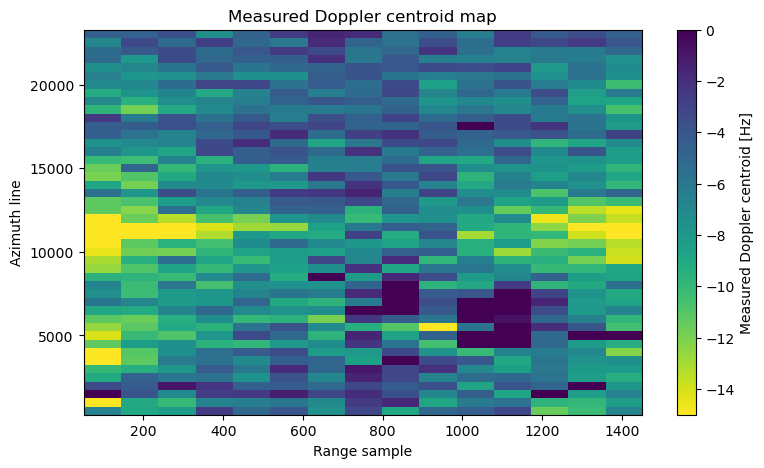

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.imshow(
    np.flipud(dop_map),
    aspect="auto",
    origin="lower",
    extent=[rg_c[0], rg_c[-1], az_c[0], az_c[-1]],
    vmin=-15, vmax=0, cmap='viridis_r'
)
plt.colorbar(label="Measured Doppler centroid [Hz]")
plt.xlabel("Range sample")
plt.ylabel("Azimuth line")
plt.title("Measured Doppler centroid map")
plt.show()

In [ ]:
import numpy as np

C = 299792458.0  # m/s

def geometric_doppler(xs: np.ndarray, vs: np.ndarray, xt: np.ndarray, radar_frequency: float) -> float:
    """
    Compute geometric Doppler [Hz] from satellite state and target position.

    xs : satellite position ECEF [m], shape (3,)
    vs : satellite velocity ECEF [m/s], shape (3,)
    xt : target position ECEF [m], shape (3,)
    radar_frequency : Hz
    """
    lam = C / radar_frequency
    r = xt - xs
    rhat = r / np.linalg.norm(r)
    fd = -(2.0 / lam) * np.dot(vs, rhat)
    return float(fd)